# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Fairuz Arfan Abhipraya
- Email: fairuzarfan@student.ub.ac.id
- Id Dicoding: CDCC006D6Y2510

## Persiapan

### Menyiapkan library yang dibutuhkan

In [16]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')

### Menyiapkan data yang akan digunakan

In [5]:
url = "https://docs.google.com/spreadsheets/d/1_TPQP7Z-r-DSZFEnV50uJYevCZ07dTKfG3-EPHISgNs/export?format=csv"
df = pd.read_csv(url, sep=',')

print(f"Jumlah baris: {len(df)}")
print(f"Jumlah kolom: {len(df.columns)}")
df.head()

Jumlah baris: 4424
Jumlah kolom: 37


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding


Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non

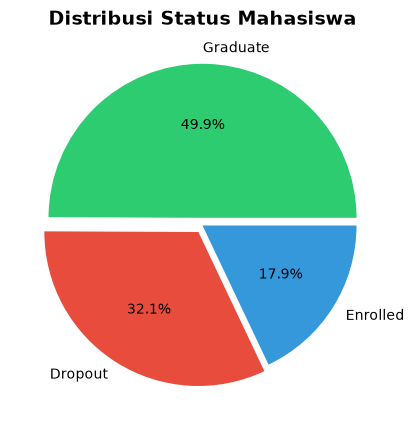

In [7]:
# 1. Informasi dataset
print("\nInformasi Dataset:")
df.info()

# 2. Statistik deskriptif
print("\nStatistik Deskriptif:")
df.describe()

# 3. Cek Missing Values
print("\nDeteksi Missing Values")

missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100
missing_df = pd.DataFrame({
    'Jumlah Missing': missing_count,
    'Persentase': missing_percent
})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Jumlah Missing', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
    print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")
else:
    print("Tidak ada missing values!")

# 4. Cek Duplikasi
print("\nDeteksi Duplikasi:")

duplicate_count = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")
print(f"Persentase duplikat: {(duplicate_count/len(df))*100:.2f}%")

if duplicate_count > 0:
    print("\nContoh data duplikat:")
    print(df[df.duplicated(keep=False)].head())
else:
    print("Tidak ada data duplikat!")

# 5. Distribusi Target (Status)
print("\nDistribusi Target (Status):")

target_counts = df['Status'].value_counts()
print(target_counts)

# Visualisasi
plt.figure(figsize=(8, 5))
colors = ['#2ecc71' if x == 'Graduate' else '#e74c3c' if x == 'Dropout' else '#3498db' for x in target_counts.index]
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', colors=colors, explode=(0.05, 0.05, 0))
plt.title('Distribusi Status Mahasiswa', fontweight='bold', fontsize=14)
plt.show()


## Data Preparation / Preprocessing

In [22]:
df_clean = df.copy()

# 1. Penanganan Missing Values
print("\nPenanganan Missing Values:")

missing_found = False

for col in df_clean.columns:
    missing_count = df_clean[col].isnull().sum()
    if missing_count > 0:
        missing_found = True
        # Jika kolom numerik, isi dengan median
        if pd.api.types.is_numeric_dtype(df_clean[col]):
            median_val = df_clean[col].median()
            df_clean[col].fillna(median_val, inplace=True)
            print(f"   {col}: diisi dengan median ({median_val:.2f})")
        # Jika kolom kategorikal, isi dengan modus
        else:
            mode_val = df_clean[col].mode()[0]
            df_clean[col].fillna(mode_val, inplace=True)
            print(f"   {col}: diisi dengan modus ({mode_val})")

if not missing_found:
    print("Tidak ada missing values")

# 2. Penanganan Duplikasi
print("\n2. Penanganan Duplikasi:")
duplicate_before = df_clean.duplicated().sum()
if duplicate_before > 0:
    df_clean.drop_duplicates(inplace=True)
    print(f"   Menghapus {duplicate_before} data duplikat")
else:
    print("   Tidak ada data duplikat")

# 3. Encode Target
print("\nEncode Target:")
le_target = LabelEncoder()
df_clean['Status_encoded'] = le_target.fit_transform(df_clean['Status'])
print(f"   Encoding Status:")
for i, status in enumerate(le_target.classes_):
    print(f"      {status} -> {i}")

# 4. Pilih fitur untuk modeling
print("\nSeleksi Fitur:")
# Hapus kolom yang tidak diperlukan
columns_to_drop = ['Status']
feature_columns = [col for col in df_clean.columns if col not in columns_to_drop]
X = df_clean[feature_columns]
y = df_clean['Status_encoded']

print(f"   Jumlah fitur: {X.shape[1]}")
print(f"   Jumlah sampel: {X.shape[0]}")

# 5. Split data
print("\nSplit Data Train Test:")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"   Train size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Test size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

# 6. Encoding fitur kategorikal
print("\nEncoding Fitur Kategorikal:")
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

print(f"   {len(categorical_cols)} fitur kategorikal berhasil di-encode")

# 7. Scaling fitur numerik
print("\nScaling Fitur Numerik:")
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_scaled[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test_scaled[numeric_cols])

print(f"   {len(numeric_cols)} fitur numerik berhasil di-scaling")

# 8. Feature Selection
print("\nFeature Selection:")
selector = SelectKBest(f_classif, k=30)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

selected_features = X_train_scaled.columns[selector.get_support()].tolist()
print(f"   {len(selected_features)} fitur terpilih dari {X_train_scaled.shape[1]} fitur")

# 0. Hapus kolom yang TIDAK PERLU
columns_to_drop = ['Status']  # Hanya drop Status

# 10. Pilih fitur (JANGAN masukkan Status_encoded)
feature_columns = [col for col in df_clean.columns if col not in ['Status', 'Status_encoded']]
X = df_clean[feature_columns]
y = df_clean['Status_encoded']

print(f"Jumlah fitur: {X.shape[1]}")
print(f"Fitur yang digunakan: {X.columns.tolist()}")


Penanganan Missing Values:
Tidak ada missing values

2. Penanganan Duplikasi:
   Tidak ada data duplikat

Encode Target:
   Encoding Status:
      Dropout -> 0
      Enrolled -> 1
      Graduate -> 2

Seleksi Fitur:
   Jumlah fitur: 37
   Jumlah sampel: 4424

Split Data Train Test:
   Train size: 3539 (80.0%)
   Test size: 885 (20.0%)

Encoding Fitur Kategorikal:
   0 fitur kategorikal berhasil di-encode

Scaling Fitur Numerik:
   37 fitur numerik berhasil di-scaling

Feature Selection:
   30 fitur terpilih dari 37 fitur
Jumlah fitur: 36
Fitur yang digunakan: ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International'

## Exploratory Data Analysis (EDA)


Analisis Target:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Analisis berdasarkan Gender:
Status     Dropout  Enrolled  Graduate
Perempuan      720       487      1661
Laki-laki      701       307       548


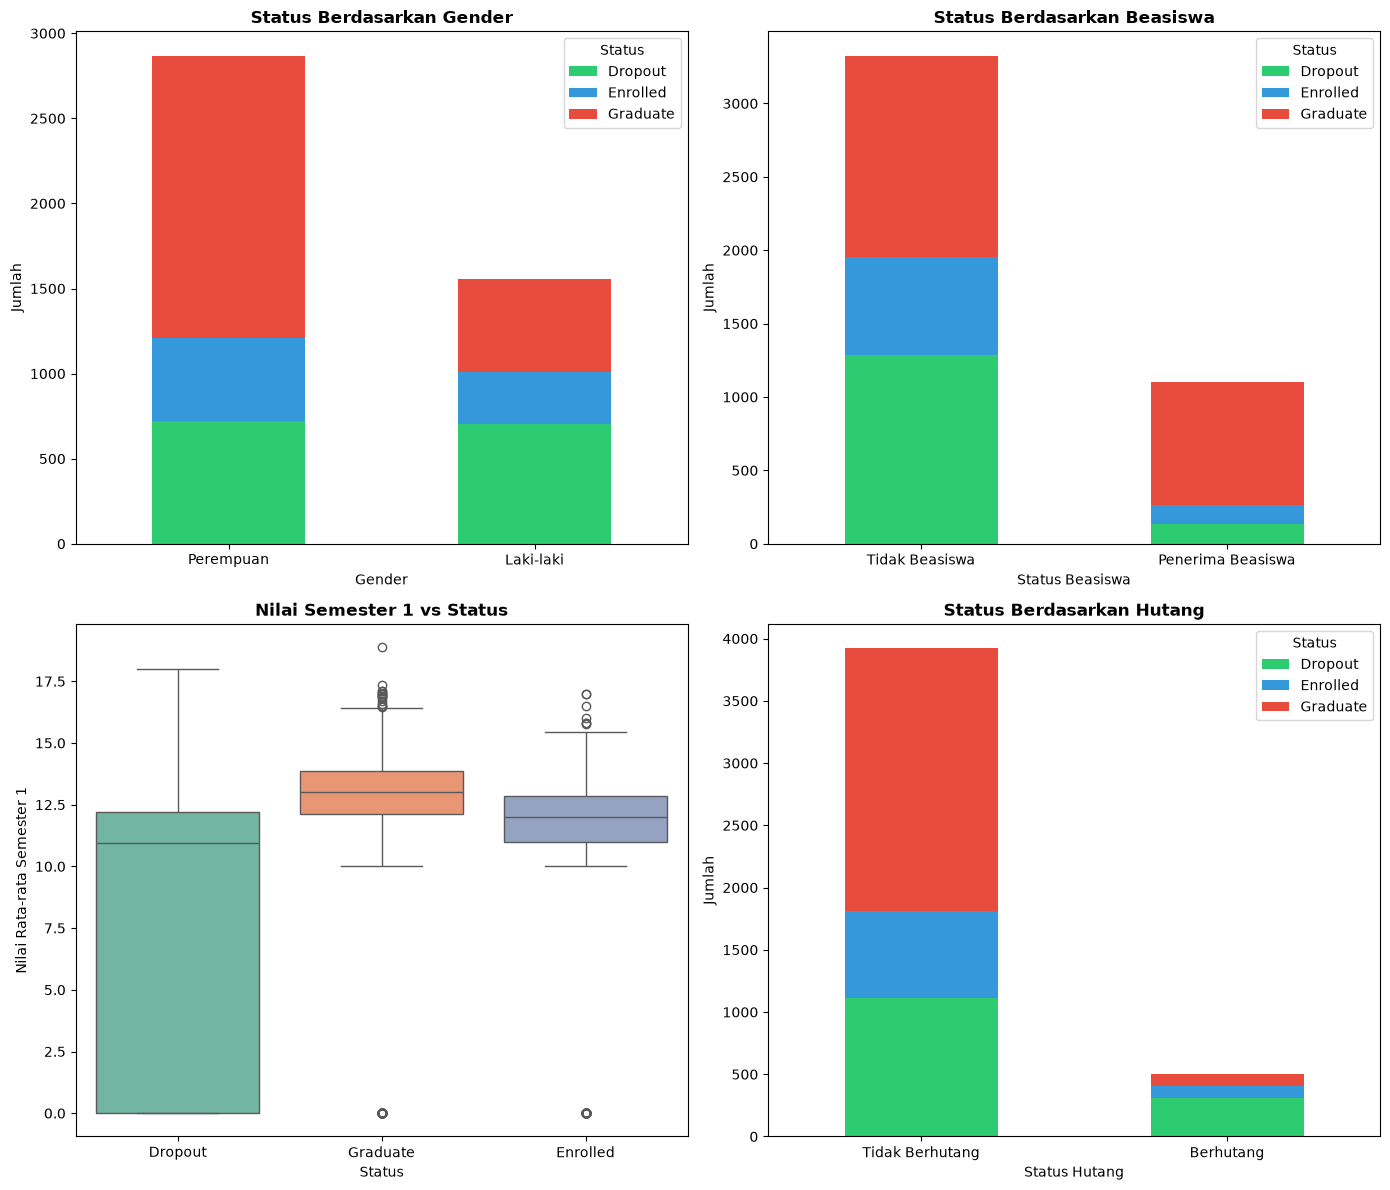

In [23]:
# 1. Analisis Target
print("\nAnalisis Target:")
print(df_clean['Status'].value_counts())

# 2. Analisis berdasarkan Gender
print("\nAnalisis berdasarkan Gender:")
gender_status = pd.crosstab(df_clean['Gender'], df_clean['Status'])
gender_status.index = ['Perempuan', 'Laki-laki']
print(gender_status)

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 2a. Gender vs Status
gender_status.plot(kind='bar', stacked=True, ax=axes[0,0], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0,0].set_title('Status Berdasarkan Gender', fontweight='bold')
axes[0,0].set_xlabel('Gender')
axes[0,0].set_ylabel('Jumlah')
axes[0,0].legend(title='Status')
axes[0,0].tick_params(axis='x', rotation=0)

# 2b. Beasiswa vs Status
scholarship_status = pd.crosstab(df_clean['Scholarship_holder'], df_clean['Status'])
scholarship_status.index = ['Tidak Beasiswa', 'Penerima Beasiswa']
scholarship_status.plot(kind='bar', stacked=True, ax=axes[0,1], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0,1].set_title('Status Berdasarkan Beasiswa', fontweight='bold')
axes[0,1].set_xlabel('Status Beasiswa')
axes[0,1].set_ylabel('Jumlah')
axes[0,1].legend(title='Status')
axes[0,1].tick_params(axis='x', rotation=0)

# 2c. Nilai Semester 1 vs Status
sns.boxplot(data=df_clean, x='Status', y='Curricular_units_1st_sem_grade', 
            palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Nilai Semester 1 vs Status', fontweight='bold')
axes[1,0].set_ylabel('Nilai Rata-rata Semester 1')

# 2d. Hutang vs Status
debtor_status = pd.crosstab(df_clean['Debtor'], df_clean['Status'])
debtor_status.index = ['Tidak Berhutang', 'Berhutang']
debtor_status.plot(kind='bar', stacked=True, ax=axes[1,1], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1,1].set_title('Status Berdasarkan Hutang', fontweight='bold')
axes[1,1].set_xlabel('Status Hutang')
axes[1,1].set_ylabel('Jumlah')
axes[1,1].legend(title='Status')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Modeling

In [24]:
# Pendefinisan model
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
}

# Train dan evaluasi
results = []
best_model = None
best_accuracy = 0

print("\nTraining models...\n")

for name, model in models.items():
    print(f"{name}")
    model.fit(X_train_selected, y_train)
    
    # Prediksi
    y_pred = model.predict(X_test_selected)
    
    # Metrik
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_model_name = name
    
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   F1-Score: {f1:.4f}\n")

# Tampilkan hasil
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print("Hasil Evaluasi Semua Model:")
print(results_df.to_string(index=False))
print(f"\nModel Terbaik: {best_model_name} dengan Accuracy: {best_accuracy:.4f}")

# Hyperparameter Tuning untuk model terbaik
print(f"Hyperparameter Tuning untuk {best_model_name}")

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    }
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }
elif best_model_name == 'XGBoost':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }
else:
    param_grid = {
        'C': [0.1, 1, 10],
        'max_iter': [1000, 2000]
    }

grid_search = GridSearchCV(best_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
print("Menjalankan Grid Search...")
grid_search.fit(X_train_selected, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Model terbaik setelah tuning
best_model_tuned = grid_search.best_estimator_
y_pred_tuned = best_model_tuned.predict(X_test_selected)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"Test accuracy after tuning: {accuracy_tuned:.4f}")

# Simpan model
if not os.path.exists('model'):
    os.makedirs('model')

joblib.dump(best_model_tuned, 'model/best_model.pkl')
joblib.dump(scaler, 'model/scaler.pkl')
joblib.dump(selector, 'model/selector.pkl')
joblib.dump(le_target, 'model/encoder_target.pkl')

for col, le in label_encoders.items():
    joblib.dump(le, f'model/encoder_{col}.pkl')


Training models...

Logistic Regression
   Accuracy: 1.0000
   F1-Score: 1.0000

K-Neighbors
   Accuracy: 0.8497
   F1-Score: 0.8468

Decision Tree
   Accuracy: 1.0000
   F1-Score: 1.0000

Random Forest
   Accuracy: 1.0000
   F1-Score: 1.0000

Gradient Boosting
   Accuracy: 1.0000
   F1-Score: 1.0000

XGBoost
   Accuracy: 1.0000
   F1-Score: 1.0000

Hasil Evaluasi Semua Model:
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  1.000000   1.000000 1.000000  1.000000
      Decision Tree  1.000000   1.000000 1.000000  1.000000
  Gradient Boosting  1.000000   1.000000 1.000000  1.000000
      Random Forest  1.000000   1.000000 1.000000  1.000000
            XGBoost  1.000000   1.000000 1.000000  1.000000
        K-Neighbors  0.849718   0.844885 0.849718  0.846848

Model Terbaik: Logistic Regression dengan Accuracy: 1.0000
Hyperparameter Tuning untuk Logistic Regression
Menjalankan Grid Search...
Best parameters: {'C': 0.1, 'max_iter': 1000}
Best cross-validat

## Evaluation


Classification Report:
              precision    recall  f1-score   support

     Dropout       1.00      1.00      1.00       284
    Enrolled       1.00      1.00      1.00       159
    Graduate       1.00      1.00      1.00       442

    accuracy                           1.00       885
   macro avg       1.00      1.00      1.00       885
weighted avg       1.00      1.00      1.00       885


Confusion Matrix:
[[284   0   0]
 [  0 159   0]
 [  0   0 442]]


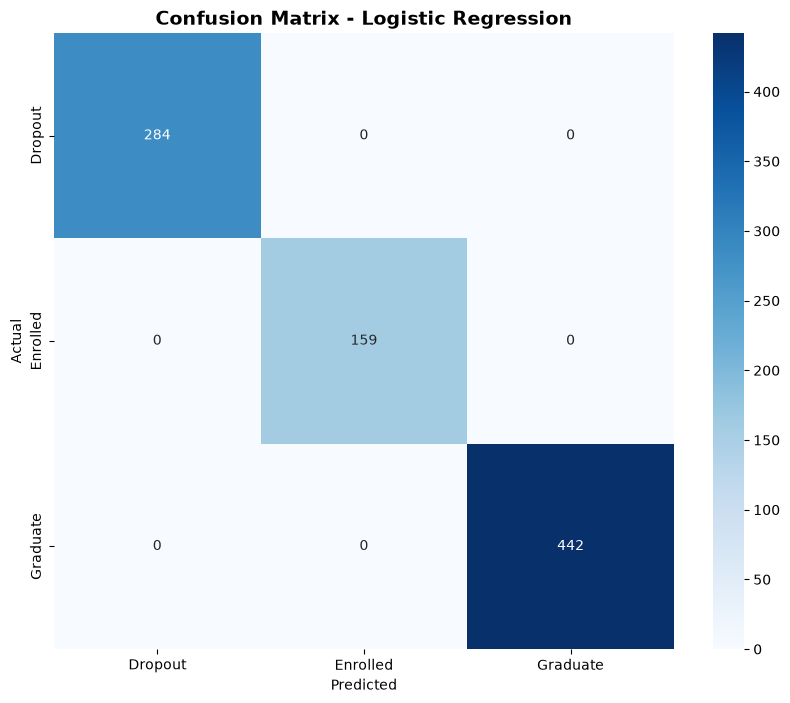


Performance Metrics:
Model: Logistic Regression
Accuracy: 1.0000
Precision (weighted): 1.0000
Recall (weighted): 1.0000
F1-Score (weighted): 1.0000

Cross-Validation:
CV Scores: [1. 1. 1. 1. 1.]
Mean CV Score: 1.0000
Std CV Score: 0.0000

Feature Importance:

Analisis Kesalahan Prediksi:
Jumlah prediksi salah: 0
Persentase error: 0.00%


In [25]:
# 1. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=le_target.classes_))

# 2. Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_tuned)
print(cm)

# Visualisasi Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 3. Performance Metrics
print("\nPerformance Metrics:")
print(f"Model: {best_model_name}")
print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"Precision (weighted): {precision_score(y_test, y_pred_tuned, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(y_test, y_pred_tuned, average='weighted'):.4f}")
print(f"F1-Score (weighted): {f1_score(y_test, y_pred_tuned, average='weighted'):.4f}")

# 4. Cross-Validation
print("\nCross-Validation:")
cv_scores = cross_val_score(best_model_tuned, X_train_selected, y_train, cv=5)
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f}")
print(f"Std CV Score: {cv_scores.std():.4f}")

# 5. Feature Importance  
print("\nFeature Importance:")
if hasattr(best_model_tuned, 'feature_importances_'):
    print("\n5. TOP 10 FEATURE IMPORTANCE")
    importances = best_model_tuned.feature_importances_
    feature_names = selected_features
    
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print(feature_importance_df.head(10).to_string(index=False))
    
    # Visualisasi
    plt.figure(figsize=(12, 8))
    top_features = feature_importance_df.head(10)
    sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
    plt.title('Top 10 Feature Importance', fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

# 6. Analisis Kesalahan Prediksi
print("\nAnalisis Kesalahan Prediksi:")
misclassified = y_test != y_pred_tuned
misclassified_indices = np.where(misclassified)[0]

print(f"Jumlah prediksi salah: {len(misclassified_indices)}")
print(f"Persentase error: {len(misclassified_indices)/len(y_test)*100:.2f}%")

if len(misclassified_indices) > 0:
    print("\nContoh data yang salah prediksi (5 data pertama):")
    for idx in misclassified_indices[:5]:
        actual = le_target.inverse_transform([y_test.iloc[idx]])[0]
        predicted = le_target.inverse_transform([y_pred_tuned[idx]])[0]
        print(f"  Index {idx}: Actual={actual}, Predicted={predicted}")